In [ ]:
# 73790d373b1141e68bac38ab50ddfbc2

In [1]:
import time
import math

import matplotlib.pyplot as plt
from torch.profiler import tensorboard_trace_handler

plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

In [2]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.tensorboard import SummaryWriter
import time
import math
import matplotlib.pyplot as plt
import random
%matplotlib inline

def train_epoch(dataloader, model, optimizer, criterion, writer, teacher_forcing):
    total_loss = 0
    for i, data in enumerate(dataloader):
        # if i%20000==0:
        #     print(i)
        # print(data)
        input_tensor, target, de, dgs, idx = data
        # print(idx)
        # print("DE:", de)
        # print("DGS:", dgs)
        # print("TEACHER FORCING:", teacher_forcing)
        
        input_tensor = input_tensor.squeeze(0)
        target_indices = target[0].squeeze(0)
        target_classes = target[1].squeeze(0)
        
        if i==0:
            try:
                writer.add_graph(model, torch.rand(*input_tensor.shape).to(device))
            except Exception as e:
                print(e)

        optimizer.zero_grad()
        # print("INPUT:", input_tensor[:, 0:5])
        # print("TARGET:", target_indices)
        # print(target_classes[:, 0:5])
        if teacher_forcing:
            _, outputs = model(input_tensor, target_tensor=target_indices)
        else:
            _, outputs = model(input_tensor)
            rows_to_add = target_indices.shape[0] - outputs.shape[0]
            if rows_to_add > 0:
                # outputs = torch.cat((outputs, torch.zeros(rows_to_add, outputs.shape[1]).to(device)), dim=0)
                outputs = torch.cat((outputs, torch.full((rows_to_add, outputs.shape[1]), -1).to(device)), dim=0)   # <PAD> tokens
            else:
                outputs = outputs[:target_indices.shape[0]]
        
        # print("OUT:", outputs)
        loss = criterion(outputs, target_indices)
        # print("LOSS:", loss)
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def train(train_dataloader, model, n_epochs, learning_rate=0.001, teacher_forcing_prob=0.7, print_every=100, plot_every=100):
    print("Training...")
    start = time.time()
    plot_losses = []
    print_loss_total = 0
    plot_loss_total = 0
    random.seed(42)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss(ignore_index=-1)
    
    writer = SummaryWriter()
    epoch_losses = []

    for epoch in range(1, n_epochs + 1):
        teacher_forcing = random.random() < teacher_forcing_prob
        loss = train_epoch(train_dataloader, model, optimizer, criterion, writer, teacher_forcing)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs), epoch, epoch / n_epochs * 100, print_loss_avg))
            writer.add_scalar('Training Loss', print_loss_avg, epoch)

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0
            writer.add_scalar('Plot Loss', plot_loss_avg, epoch)
            
        epoch_losses.append(loss)

    showPlot(plot_losses)
    writer.close()
    
    return epoch_losses
    
def evaluate(model, sentence):
    with torch.no_grad():
        input_tensor = model.sentence2vec(sentence)
        outputs, _ = model(input_tensor)      
        decoded_words = model.decode_sequence(outputs)
        
    return decoded_words

def evaluate_randomly(model, dataloader, n=10):
    for i, data in zip(range(n), dataloader):
        input_tensor, target, de, dgs, idx = data
        input_tensor = input_tensor.squeeze(0)
        
        de, dgs = de[0], dgs[0]
        
        print('>', de)
        print('=', dgs)
        output_words = evaluate(model, de)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')
        
def show_state_dict(model):
    print("Model's state_dict:")
    for param_tensor in model.state_dict():
        print(param_tensor, "\t", model.state_dict()[param_tensor].size())
        
def plot_training_progress(losses):
    plt.figure()
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Progress')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
from torch.utils.data import DataLoader
from dataset import DgsDataset
from seq2seq import Seq2Seq

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = DgsDataset('vocab/translations/dgs_korpus.pkl')
subset = torch.utils.data.Subset(ds, list(range(0, 50)))
dl = DataLoader(subset, batch_size=1, shuffle=True)

hidden_size = 128

s2s = Seq2Seq(ds.vocabulary, ds.max_tokens, hidden_size=hidden_size).to(device)
# s2s.load_state_dict(torch.load("state_dict.pt"))
# show_state_dict(s2s)

Training...


<Figure size 640x480 with 0 Axes>

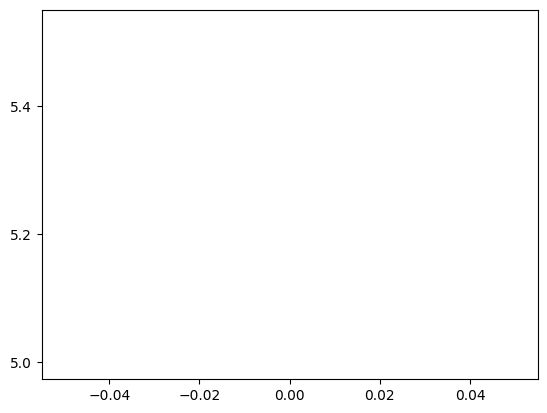

In [7]:
losses = train(dl, s2s, 1, learning_rate=0.001, teacher_forcing_prob=0.5, print_every=10, plot_every=1)

In [ ]:
s2s.eval()
torch.save(s2s.state_dict(), 'state_dict.pt')
evaluate_randomly(s2s, dl)

In [ ]:
# plot_training_progress(losses)

In [ ]:
# test_input = s2s.sentence2vec("Er trinkt gerne Mineralwasser.")
# test_output, _ = s2s(test_input)
# test_decoded_output = s2s.decode_sequence(test_output)
# print(test_output)
# print(test_decoded_output)

In [ ]:
# print(ds.__getitem__(1066))
# print(ds.__getitem__(1067))

In [ ]:
# index = 49734
# print(ds.de[index])
# print(ds.dgs[index])
# _, dgs_tensor, _, dgs_string, _ = ds.__getitem__(index)
# print(dgs_tensor[0])
# for e in dgs_tensor[0]:
#     print(s2s.idx2token[int(e)])
# test = s2s.encode_dgs(dgs_string)

ValueError                                Traceback (most recent call last)
Input In [4], in <cell line: 16>()
     12 s2s = Seq2Seq(ds.vocabulary, ds.max_tokens, hidden_size=hidden_size).to(device)
     13 # s2s.load_state_dict(torch.load("state_dict.pt"))
     14 # show_state_dict(s2s)
---> 16 losses = train(dl, s2s, 10, learning_rate=0.001, teacher_forcing_prob=0.7, print_every=1, plot_every=1)

Input In [3], in train(train_dataloader, model, n_epochs, learning_rate, teacher_forcing_prob, print_every, plot_every)
     69 for epoch in range(1, n_epochs + 1):
     70     teacher_forcing = random.random() < teacher_forcing_prob
---> 71     loss = train_epoch(train_dataloader, model, optimizer, criterion, writer, teacher_forcing)
     72     print_loss_total += loss
     73     plot_loss_total += loss

Input In [3], in train_epoch(dataloader, model, optimizer, criterion, writer, teacher_forcing)
     43         outputs = outputs[:target_indices.shape[0]]
     45 # print("OUT:", outputs)
---> 46 loss = criterion(outputs, target_indices)
     47 # print("LOSS:", loss)
     48 loss.backward()

File ~/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1532, in Module._wrapped_call_impl(self, *args, **kwargs)
   1530     return self._compiled_call_impl(*args, **kwargs)  # type: ignore[misc]
   1531 else:
-> 1532     return self._call_impl(*args, **kwargs)

File ~/.local/lib/python3.10/site-packages/torch/nn/modules/module.py:1541, in Module._call_impl(self, *args, **kwargs)
   1536 # If we don't have any hooks, we want to skip the rest of the logic in
   1537 # this function, and just call forward.
   1538 if not (self._backward_hooks or self._backward_pre_hooks or self._forward_hooks or self._forward_pre_hooks
   1539         or _global_backward_pre_hooks or _global_backward_hooks
   1540         or _global_forward_hooks or _global_forward_pre_hooks):
-> 1541     return forward_call(*args, **kwargs)
   1543 try:
   1544     result = None

File ~/.local/lib/python3.10/site-packages/torch/nn/modules/loss.py:216, in NLLLoss.forward(self, input, target)
    215 def forward(self, input: Tensor, target: Tensor) -> Tensor:
--> 216     return F.nll_loss(input, target, weight=self.weight, ignore_index=self.ignore_index, reduction=self.reduction)

File ~/.local/lib/python3.10/site-packages/torch/nn/functional.py:2760, in nll_loss(input, target, weight, size_average, ignore_index, reduce, reduction)
   2758 if size_average is not None or reduce is not None:
   2759     reduction = _Reduction.legacy_get_string(size_average, reduce)
-> 2760 return torch._C._nn.nll_loss_nd(input, target, weight, _Reduction.get_enum(reduction), ignore_index)

ValueError: Expected input batch_size (48) to match target batch_size (49).

In [ ]:
# s2s.token2idx["$INDEX1"]